# HVM Sweep Results
Loads all `checkpoints/hvm/*/siglip/*/best.pt` and compares performance across:
- Model architecture (MLP / LSTM / Transformer)
- Category conditioning (with vs without)
- Hyperparameters (bottleneck/hidden/d_model, lr, weight_decay)

Primary metric: **val 2-AFC identification**. Secondary: val/test cosine similarity.

In [1]:
import sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

sys.path.insert(0, '..')
from config_const import CHECKPOINT_DIR

HVM_CKPT_ROOT = CHECKPOINT_DIR / 'hvm'

def load_one(pt):
    try:
        ckpt = torch.load(pt, weights_only=False, map_location='cpu')
    except Exception as e:
        return None
    if 'metrics' not in ckpt:
        return None
    row = {**ckpt['args'], **ckpt['metrics'], 'path': str(pt)}
    if 'test_metrics' in ckpt:
        row.update(ckpt['test_metrics'])
    return row

candidates = sorted(HVM_CKPT_ROOT.glob('*/siglip/*/best.pt'))
print(f'Found {len(candidates)} checkpoints')

records = []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(load_one, pt): pt for pt in candidates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc='Loading'):
        row = fut.result()
        if row:
            records.append(row)

df = pd.DataFrame(records)
has_test = 'test_2afc' in df.columns

# Normalise use_category to bool
if 'use_category' in df.columns:
    df['use_category'] = df['use_category'].astype(bool)
else:
    df['use_category'] = False

print(f'{len(df)} runs loaded  |  test_metrics: {has_test}')
print(df.groupby(['model', 'use_category']).size().to_string())

Found 80 checkpoints


Loading:   0%|          | 0/80 [00:00<?, ?it/s]

80 runs loaded  |  test_metrics: True
model        use_category
lstm         False           16
             True            16
mlp          False            8
             True             8
transformer  False           16
             True            16


In [2]:
def make_arch(row):
    m = row['model']
    if m == 'mlp':
        return f"bn{int(row['bottleneck'])}"
    elif m == 'lstm':
        return f"h{int(row['hidden'])}_nl{int(row['n_layers'])}"
    else:
        return f"d{int(row['d_model'])}_nl{int(row['n_layers'])}"

df['arch'] = df.apply(make_arch, axis=1)
df['cat_label'] = df['use_category'].map({True: 'cat', False: 'no_cat'})

MODELS = sorted(df['model'].unique())
MODEL_PALETTE = dict(zip(MODELS, ['tab:blue', 'tab:orange', 'tab:green']))
CAT_STYLE = {True: dict(marker='o', ls='-', label='conditioned'), 
             False: dict(marker='s', ls='--', label='unconditioned')}
print(f'Models: {MODELS}')

Models: ['lstm', 'mlp', 'transformer']


## Best run per model × conditioning

In [3]:
cols = ['model', 'use_category', 'arch', 'dropout', 'lr', 'weight_decay',
        'epoch', 'train_loss', 'val_loss', 'val_2afc', 'val_cos_sim',
        'test_2afc', 'test_top1', 'test_top5', 'test_top10']
available = [c for c in cols if c in df.columns]

summary = (
    df.sort_values('val_2afc', ascending=False)
      .groupby(['model', 'use_category'], sort=False)
      .first()
      .reset_index()
)[available]
display(summary)

,model,use_category,arch,dropout,lr,weight_decay,epoch,train_loss,val_loss,val_2afc,val_cos_sim,test_2afc,test_top1,test_top5,test_top10
0,mlp,True,bn256,0.1,0.0010,0.01,135,0.079924,0.135460,0.967541,0.862381,0.969538,0.300000,0.744444,0.977778
1,lstm,True,h256_nl1,0.1,0.0010,0.10,167,0.067097,0.165465,0.965793,0.832807,0.965418,0.266667,0.733333,0.944444
2,transformer,True,d64_nl1,0.1,0.0010,0.10,172,0.119687,0.177176,0.933458,0.824181,0.935705,0.255556,0.611111,0.811111
3,transformer,False,d128_nl1,0.1,0.0003,0.10,157,0.144957,0.234681,0.817353,0.770367,0.805868,0.122222,0.311111,0.522222
4,mlp,False,bn256,0.1,0.0010,0.01,175,0.077599,0.151966,0.809988,0.852444,0.802871,0.088889,0.333333,0.544444
5,lstm,False,h256_nl1,0.1,0.0010,0.01,137,0.077097,0.235402,0.773283,0.768306,0.759551,0.066667,0.277778,0.422222


## Category conditioning: lift in 2-AFC and cosine similarity

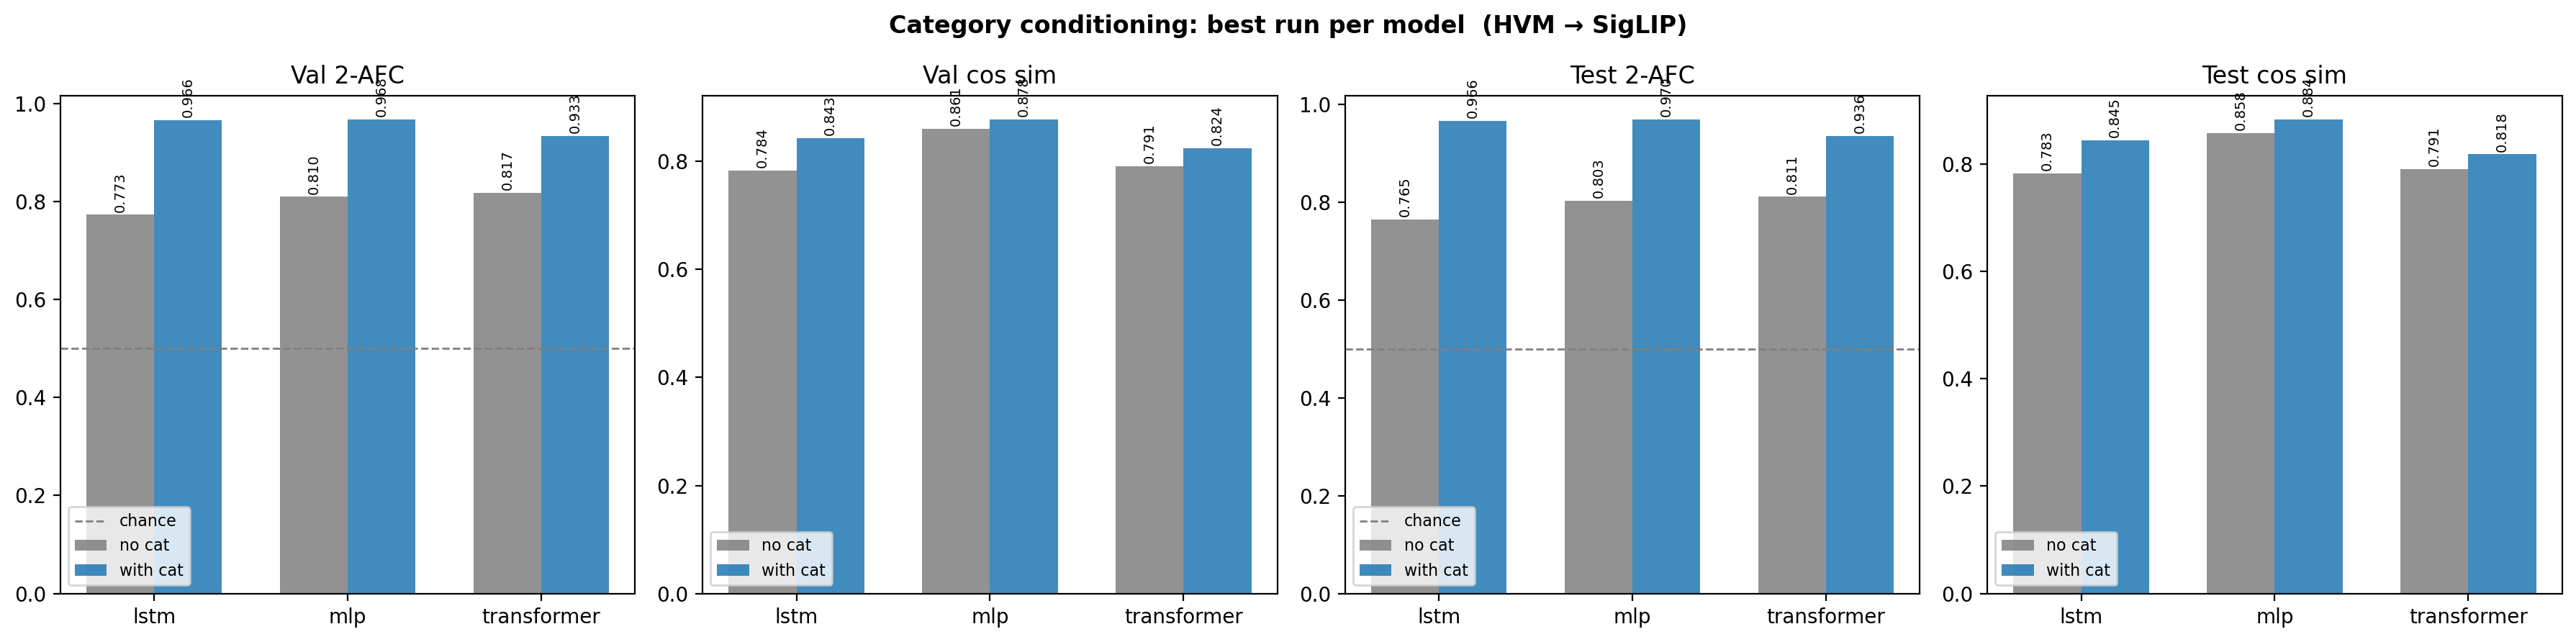

In [4]:
metrics = [('val_2afc', 'Val 2-AFC'), ('val_cos_sim', 'Val cos sim')]
if has_test:
    metrics += [('test_2afc', 'Test 2-AFC'), ('test_cos_sim', 'Test cos sim')]
metrics = [(m, l) for m, l in metrics if m in df.columns]

fig, axes = plt.subplots(1, len(metrics), figsize=(4.5 * len(metrics), 4.5))
if len(metrics) == 1:
    axes = [axes]

x = np.arange(len(MODELS))
width = 0.35

for ax, (metric, label) in zip(axes, metrics):
    best = (
        df.sort_values(metric, ascending=False)
          .groupby(['model', 'use_category'])
          .first()
          .reset_index()
    )
    for i, use_cat in enumerate([False, True]):
        vals = [best.loc[(best['model'] == m) & (best['use_category'] == use_cat), metric]
                     .values for m in MODELS]
        heights = [float(v[0]) if len(v) > 0 else 0.0 for v in vals]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, heights, width,
                      label='with cat' if use_cat else 'no cat',
                      color=['tab:blue' if use_cat else 'tab:gray'],
                      alpha=0.85)
        for bar, h in zip(bars, heights):
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                        f'{h:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)
    if 'afc' in metric:
        ax.axhline(0.5, color='grey', lw=1, ls='--', label='chance')
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS)
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.suptitle('Category conditioning: best run per model  (HVM → SigLIP)', fontweight='bold')
plt.tight_layout()
plt.show()

## All runs: val 2-AFC distribution by model and conditioning

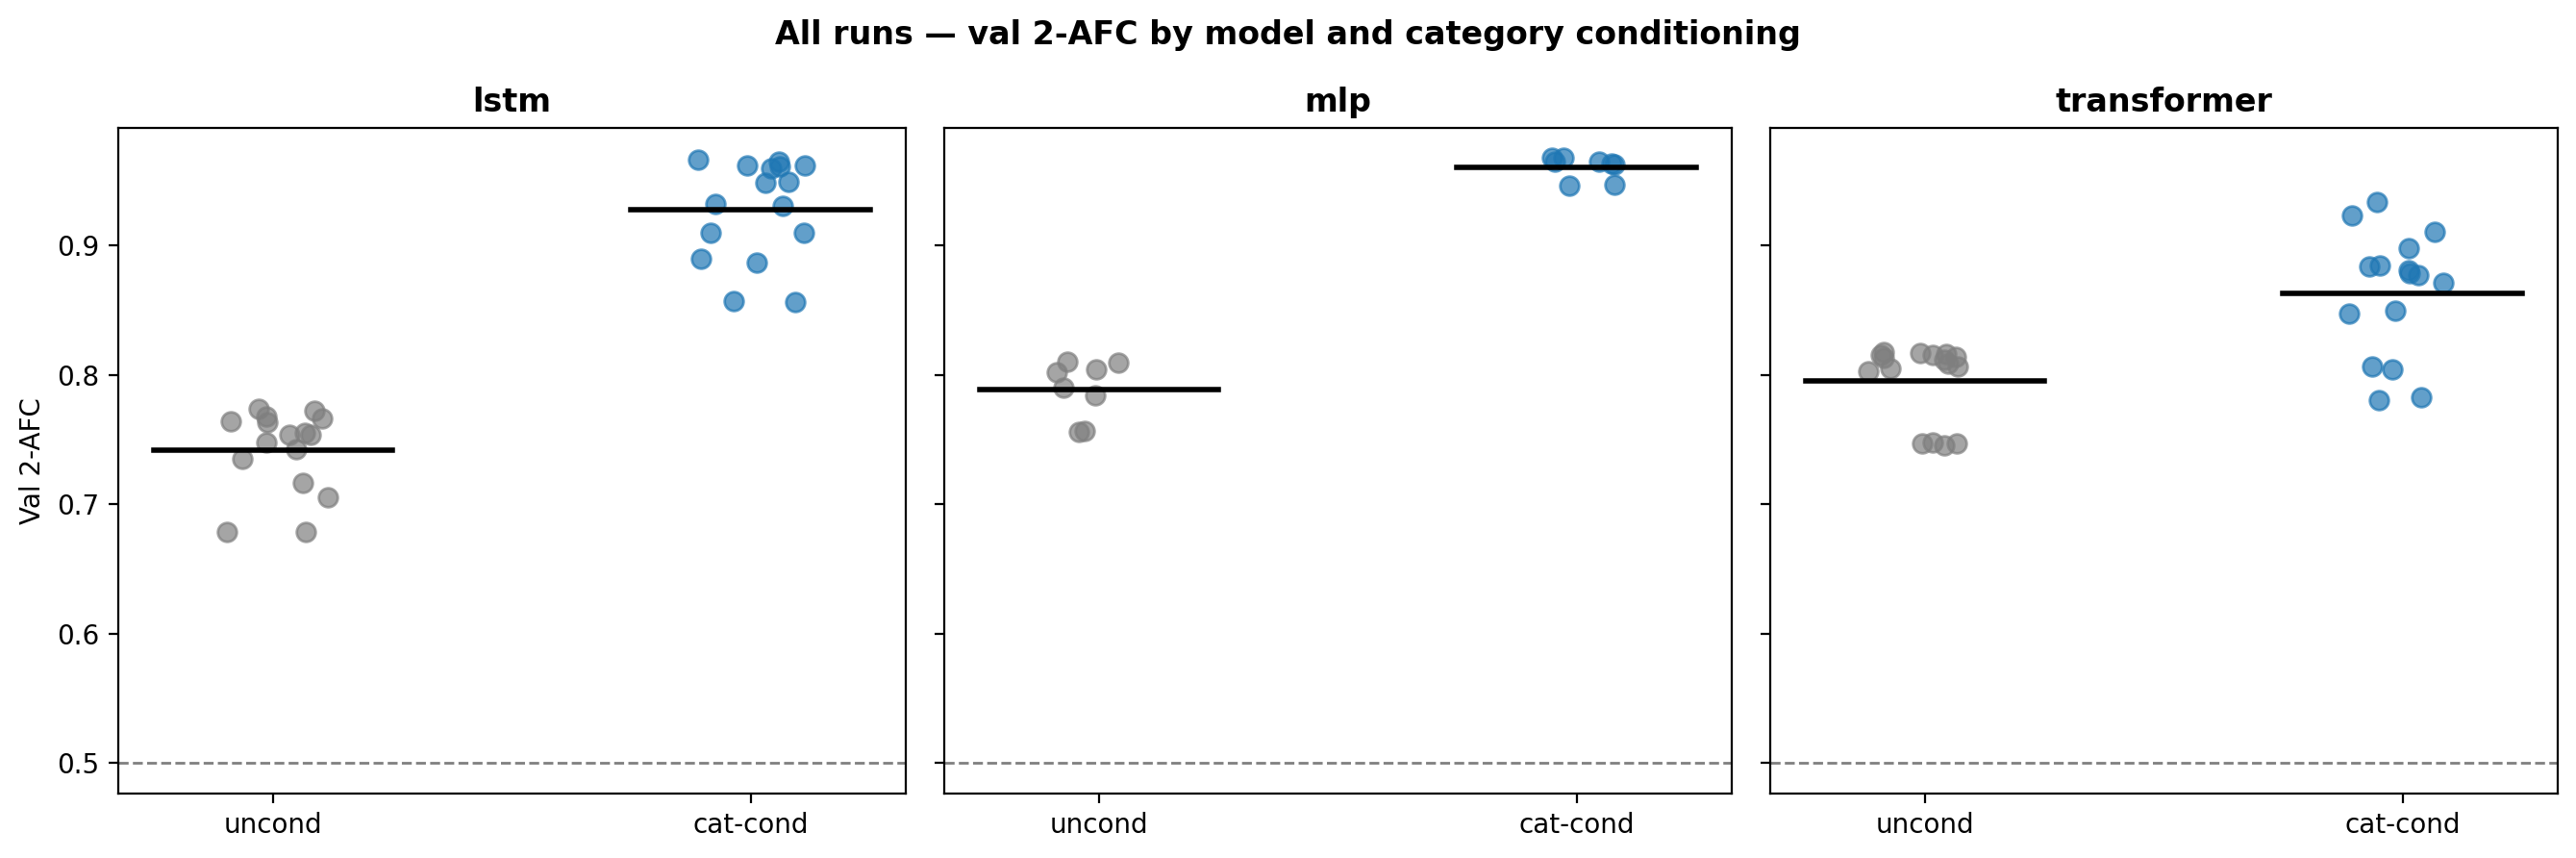

In [5]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(4.5 * len(MODELS), 4.5), sharey=True)
rng = np.random.default_rng(42)

for ax, model in zip(axes, MODELS):
    sub = df[df['model'] == model]
    for use_cat in [False, True]:
        grp = sub[sub['use_category'] == use_cat]['val_2afc'].dropna().values
        if not len(grp):
            continue
        x_pos = 1 if use_cat else 0
        jitter = rng.uniform(-0.12, 0.12, len(grp))
        color = 'tab:blue' if use_cat else 'tab:gray'
        ax.scatter(np.full(len(grp), x_pos) + jitter, grp,
                   color=color, alpha=0.7, s=50)
        ax.plot([x_pos - 0.25, x_pos + 0.25], [grp.mean()] * 2, 'k-', lw=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['uncond', 'cat-cond'])
    ax.set_title(model, fontweight='bold')
    ax.axhline(0.5, color='grey', lw=1, ls='--')
    if ax is axes[0]:
        ax.set_ylabel('Val 2-AFC')

fig.suptitle('All runs — val 2-AFC by model and category conditioning', fontweight='bold')
plt.tight_layout()
plt.show()

## 2-AFC by hyperparameter

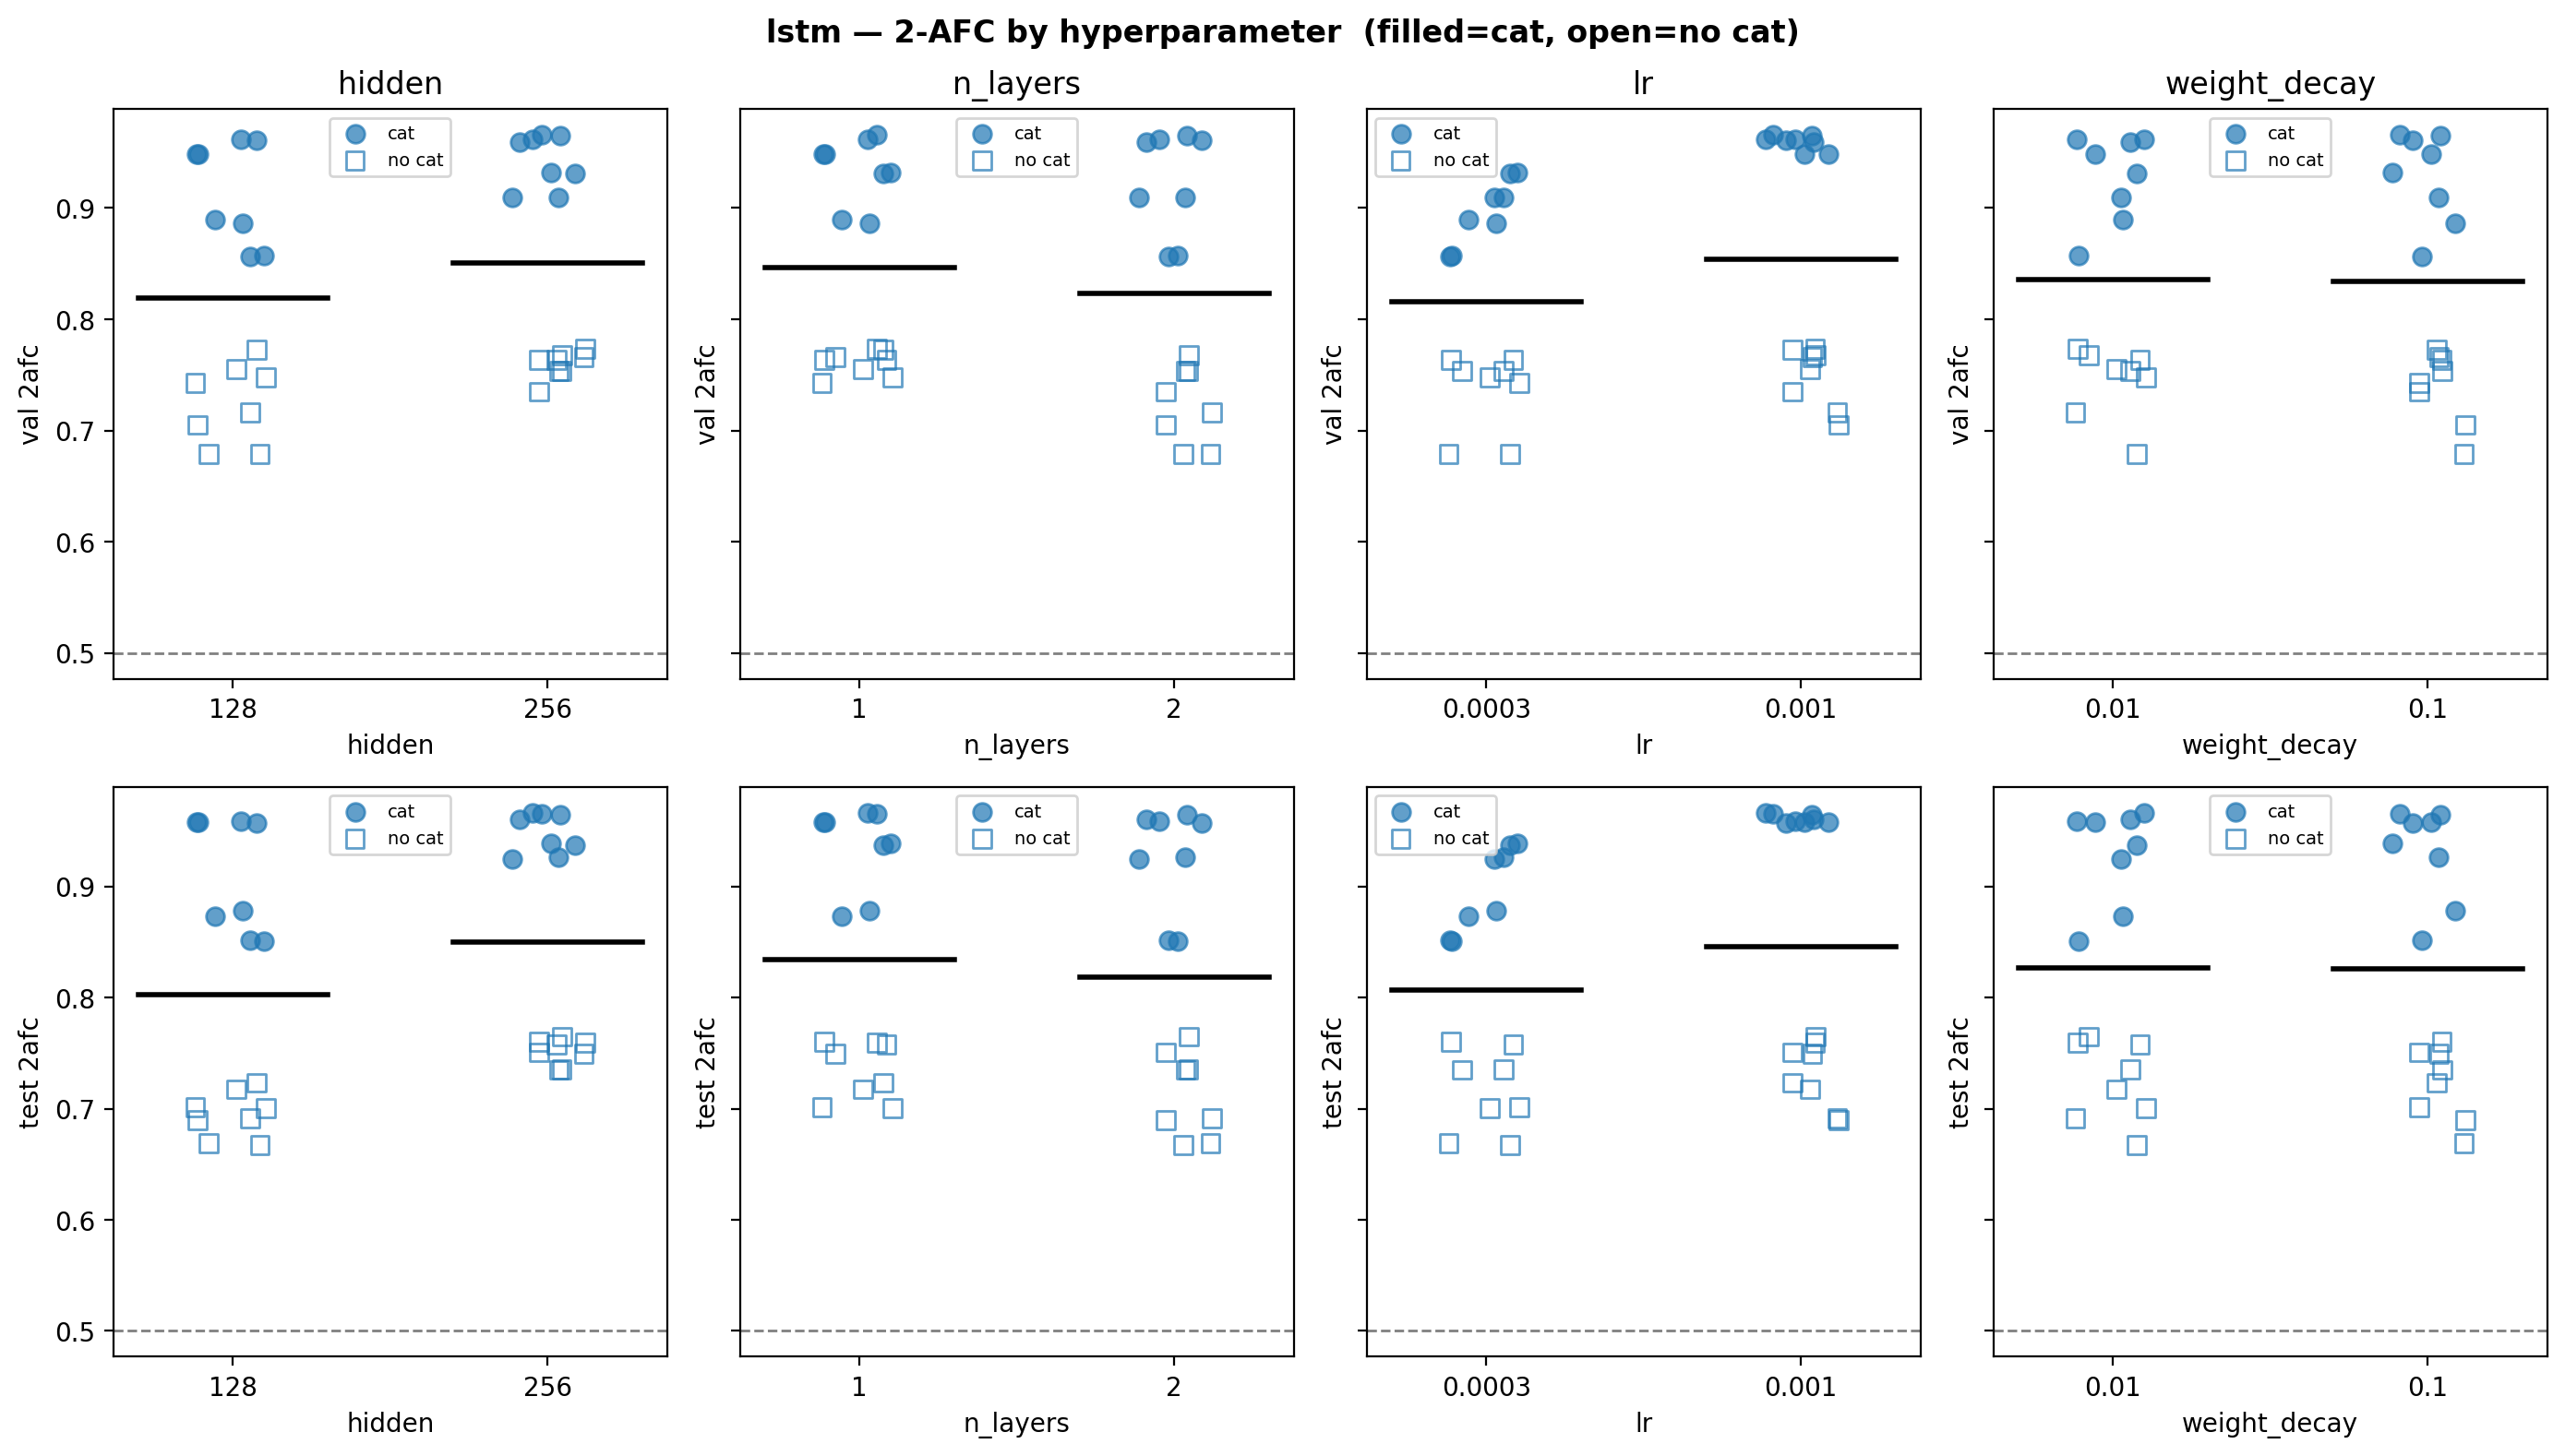

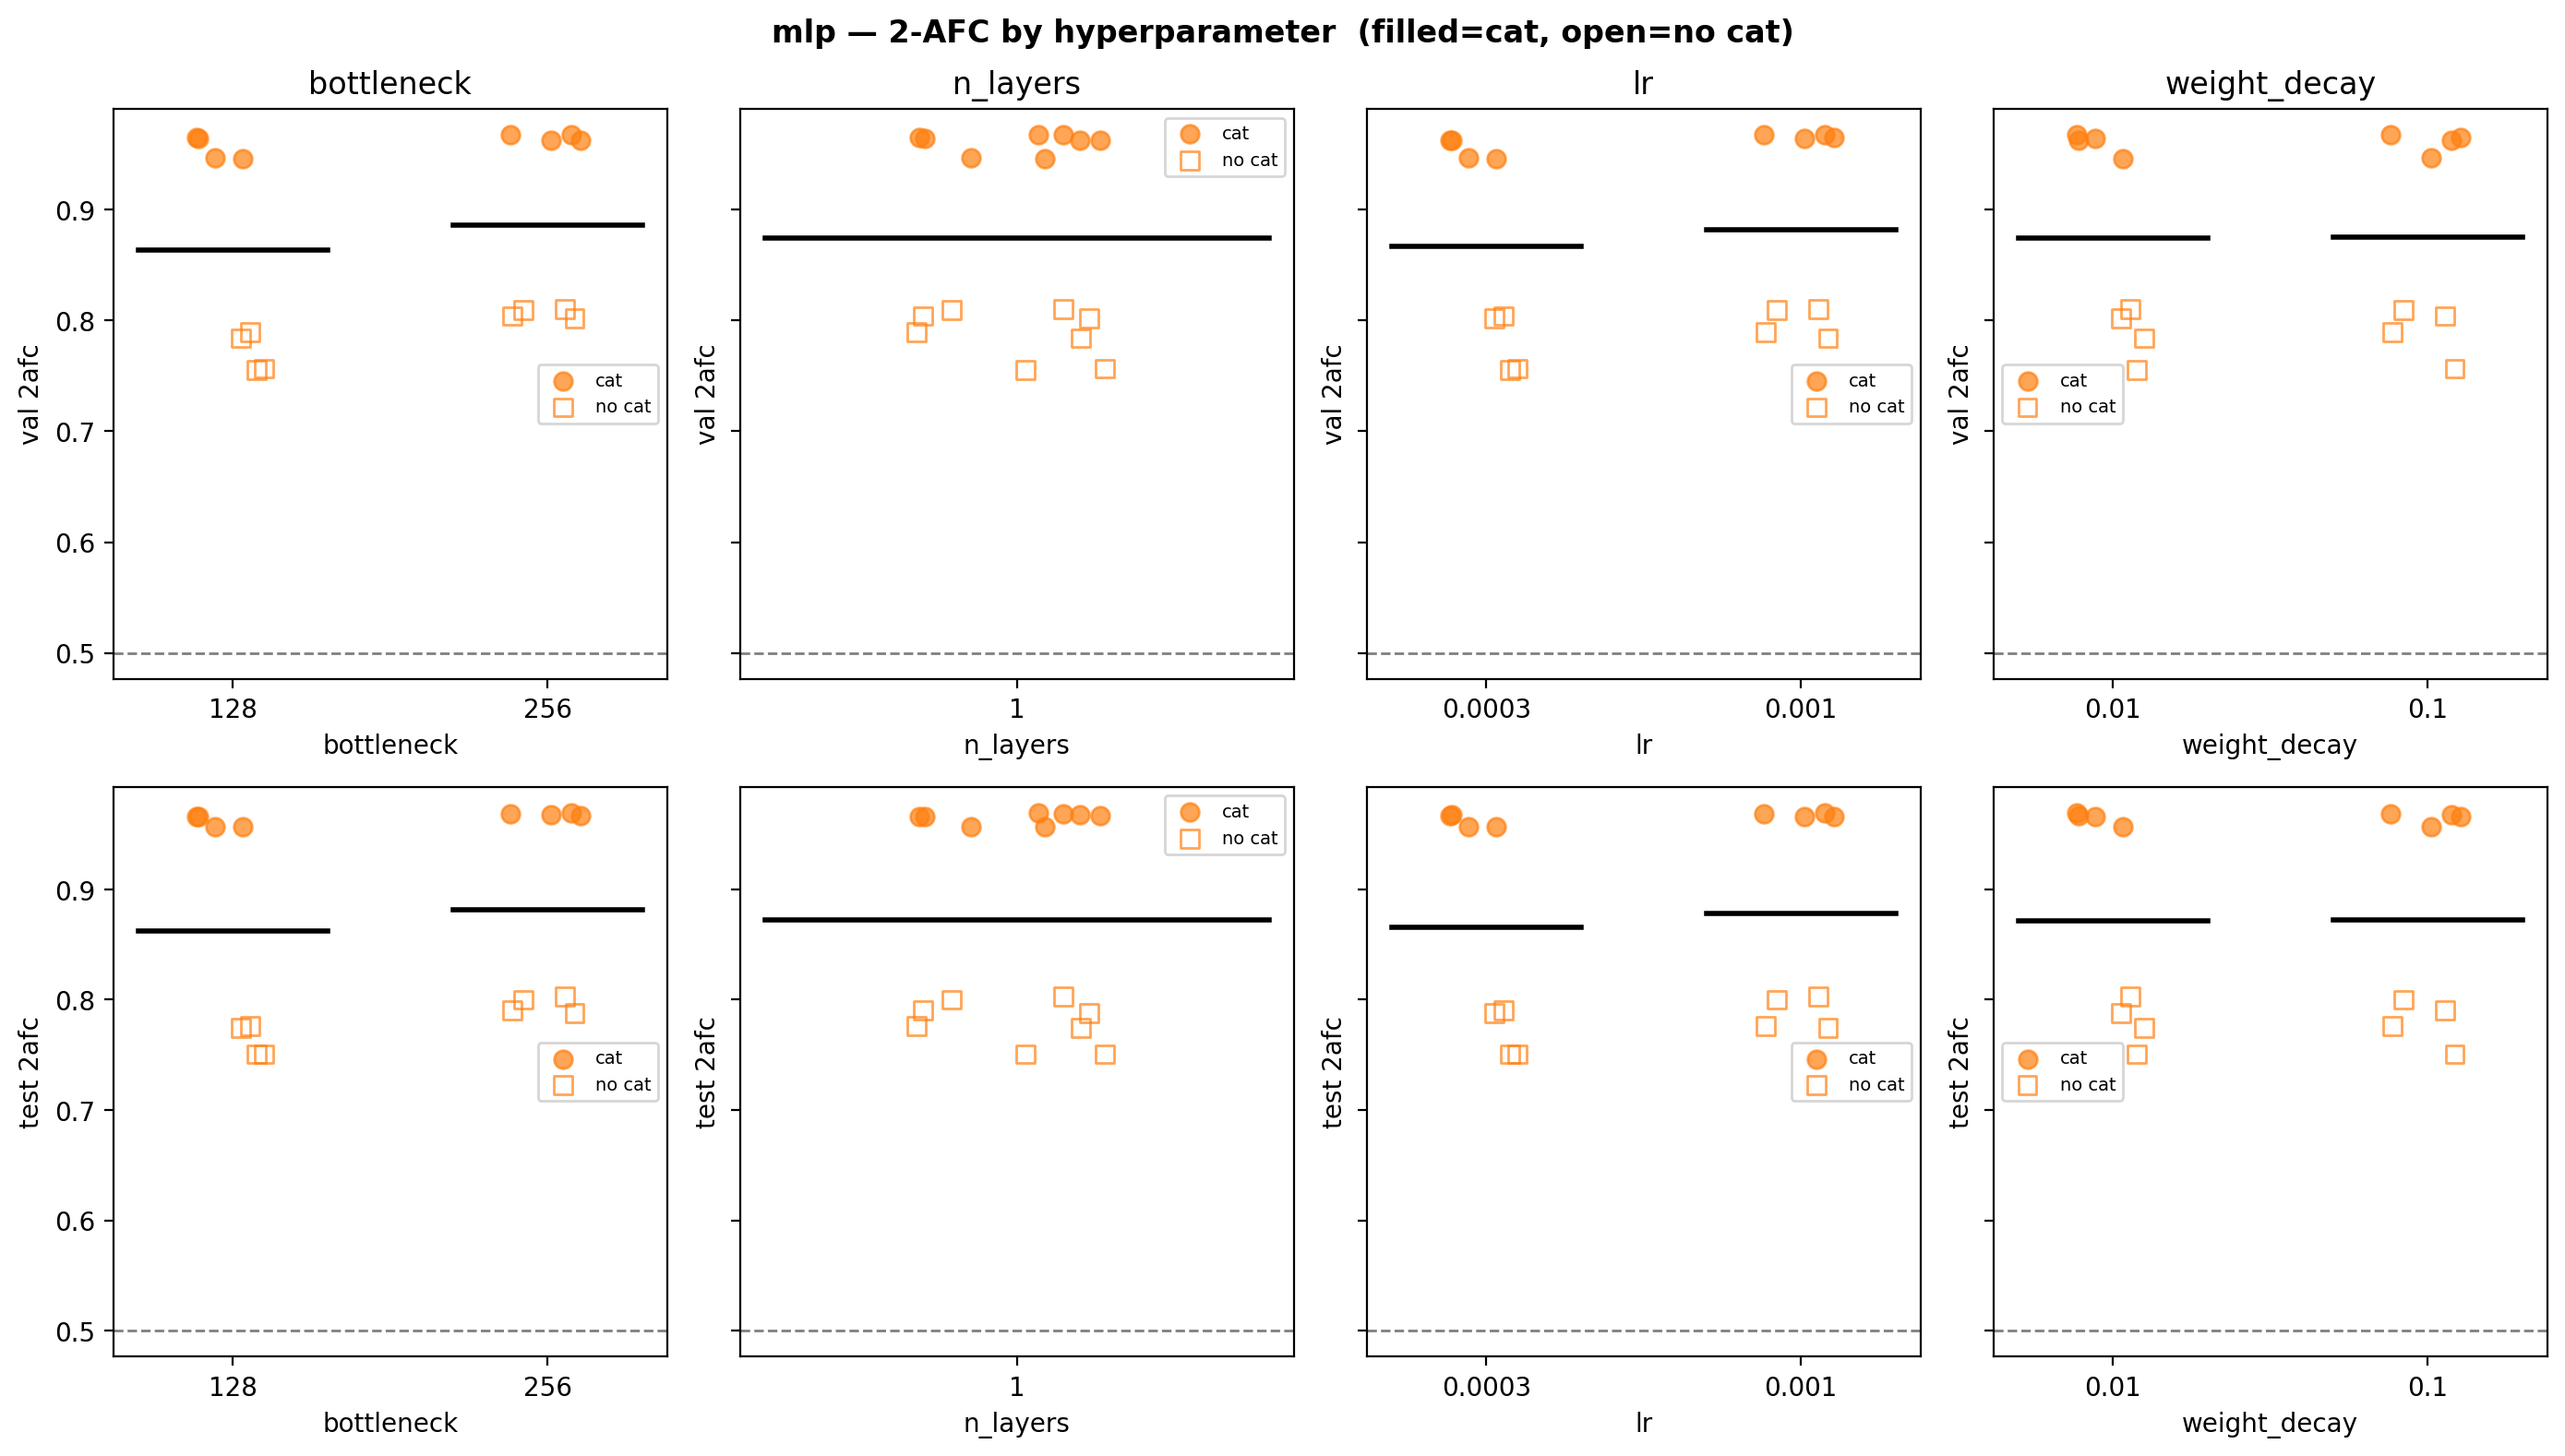

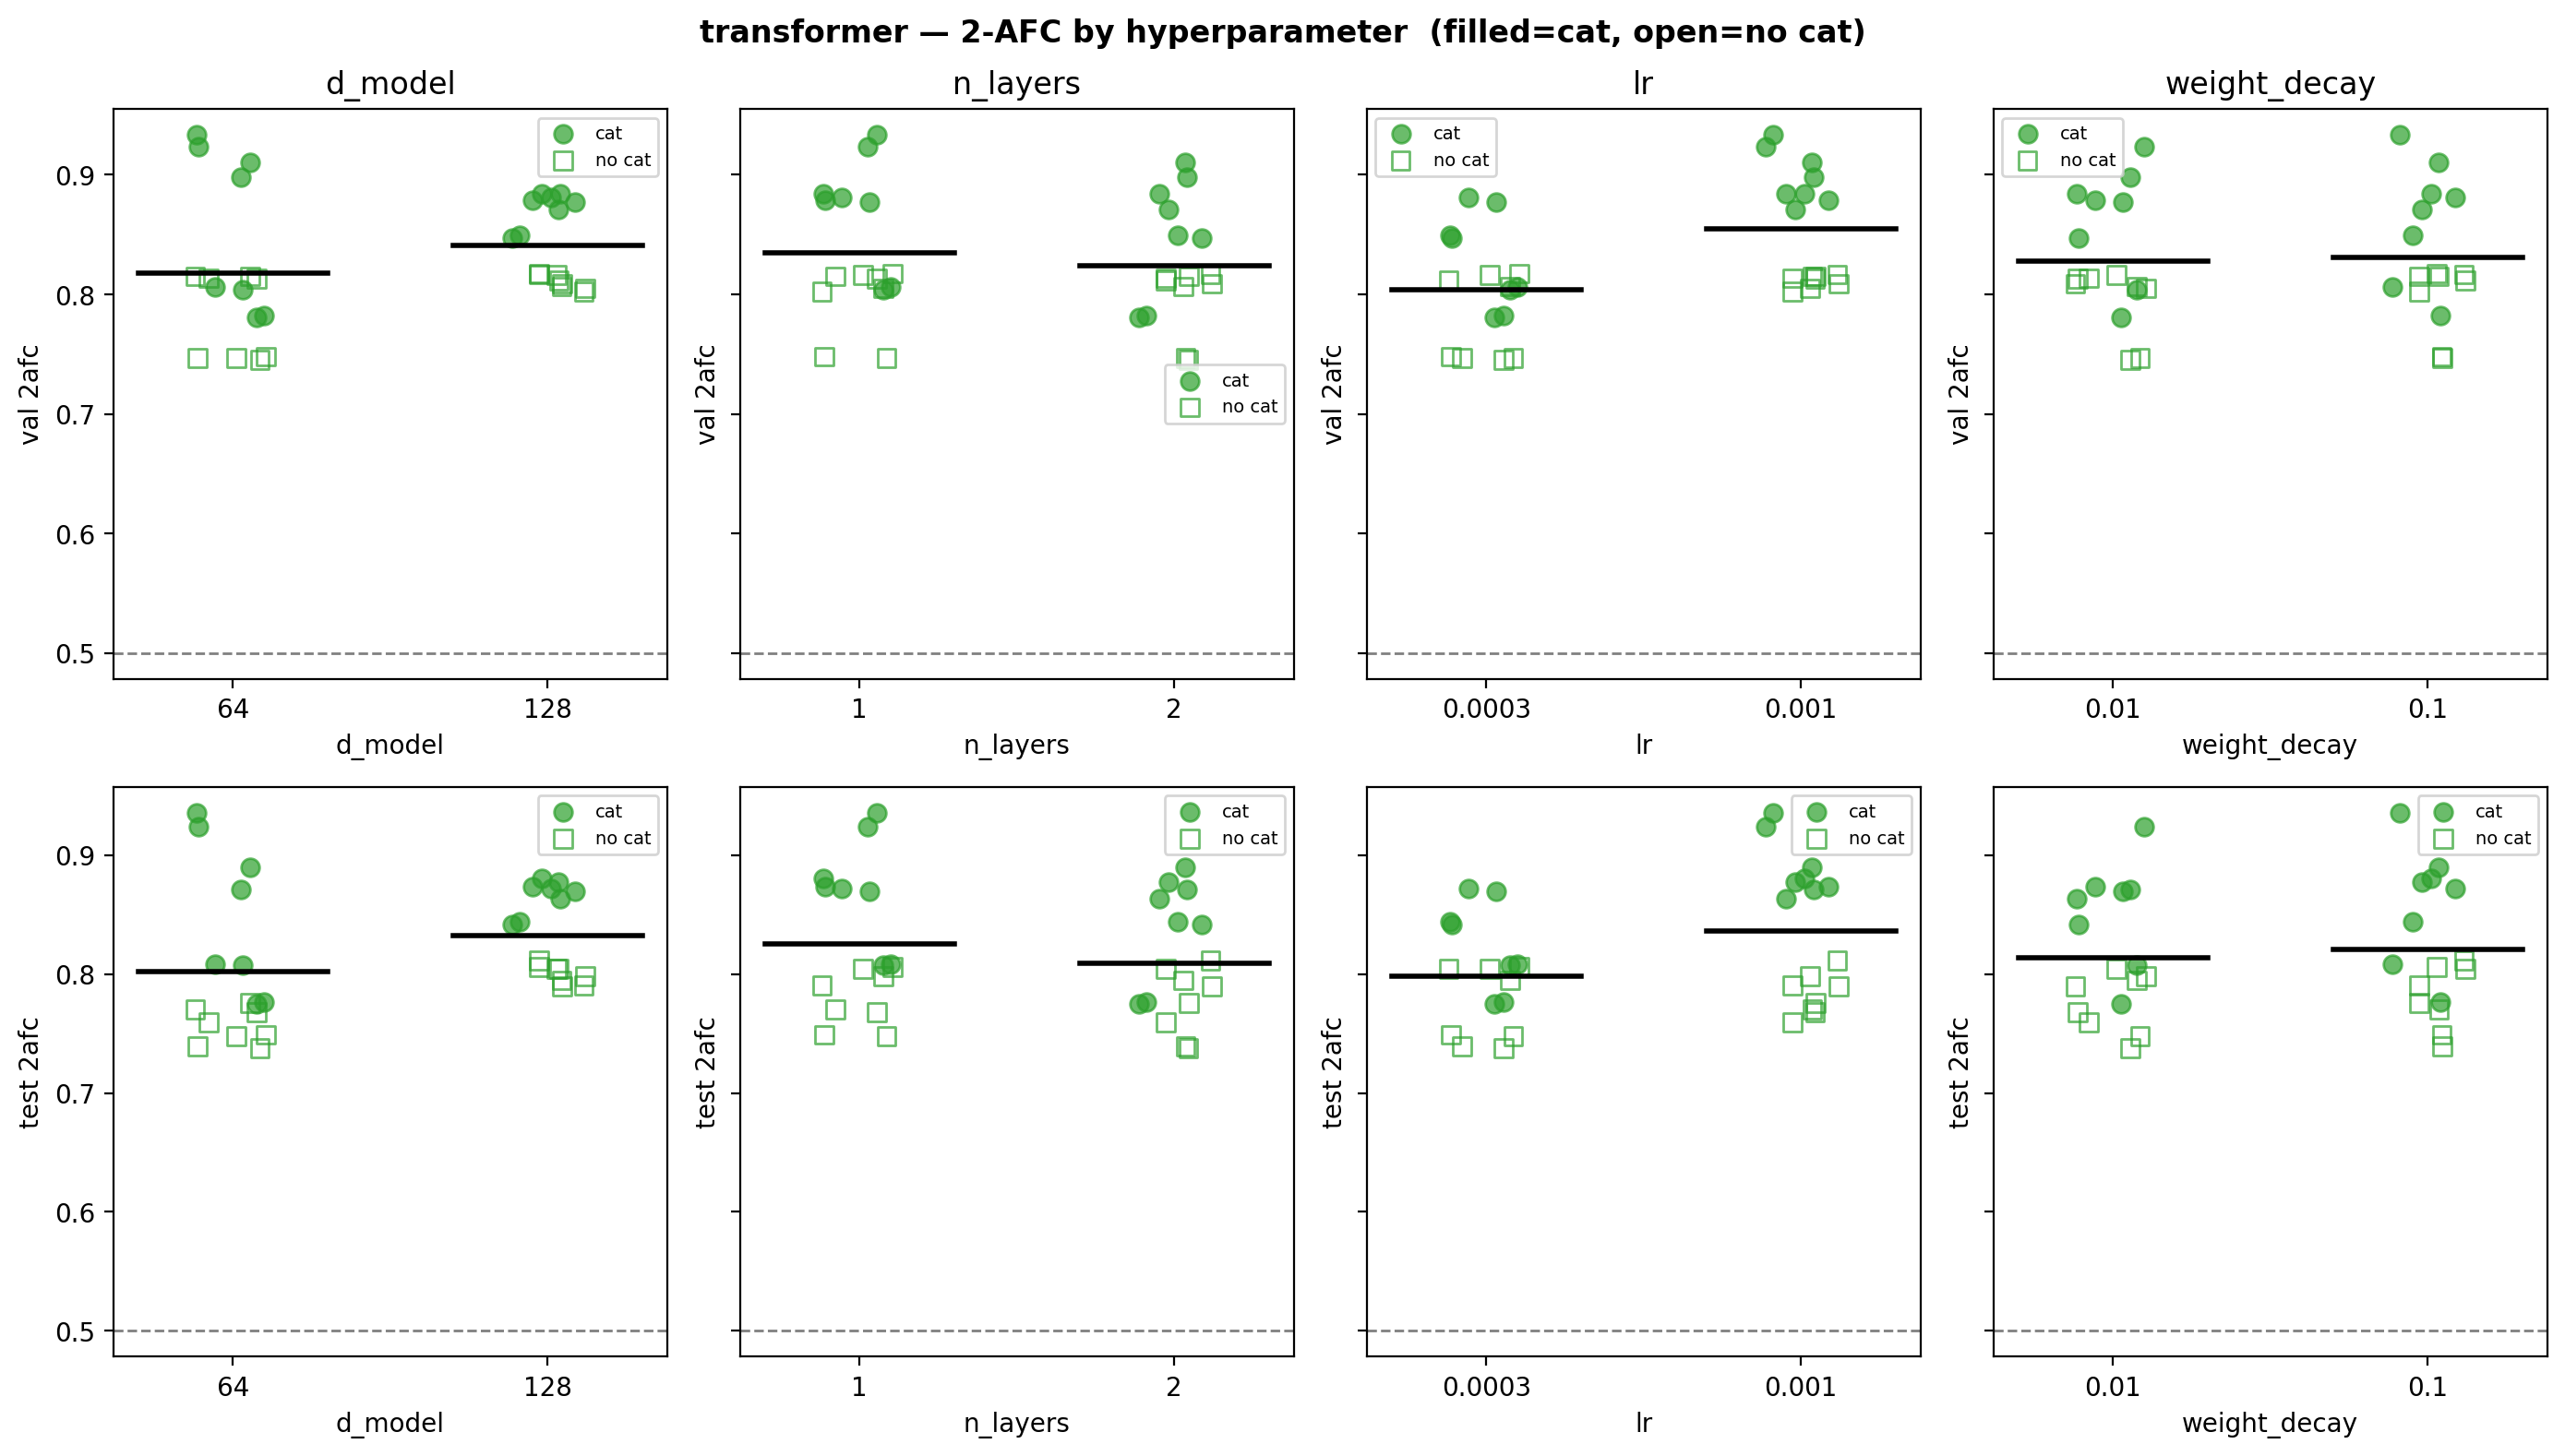

In [6]:
ARCH_PARAM = {'mlp': 'bottleneck', 'lstm': 'hidden', 'transformer': 'd_model'}
# filled marker = cat-conditioned, open marker = unconditioned
CAT_STYLE = {
    True:  dict(marker='o', facecolor=None,   label_suffix=''),
    False: dict(marker='s', facecolor='none',  label_suffix=' (no cat)'),
}

def strip_plot(ax, grp, x_col, title, color='tab:blue', metric_col='val_2afc'):
    levels = sorted(grp[x_col].dropna().unique())
    rng = np.random.default_rng(0)
    for i, lvl in enumerate(levels):
        for use_cat, sty in CAT_STYLE.items():
            vals = grp.loc[(grp[x_col] == lvl) & (grp['use_category'] == use_cat), metric_col].values
            if not len(vals):
                continue
            jitter = rng.uniform(-0.12, 0.12, len(vals))
            fc = color if sty['facecolor'] is None else 'none'
            ax.scatter(np.full(len(vals), i) + jitter, vals,
                       alpha=0.7, s=50, color=color, edgecolors=color, facecolors=fc,
                       marker=sty['marker'],
                       label=('cat' if use_cat else 'no cat') if i == 0 else '_')
        all_vals = grp.loc[grp[x_col] == lvl, metric_col].values
        if len(all_vals):
            ax.plot([i - 0.3, i + 0.3], [all_vals.mean()] * 2, 'k-', lw=2)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(l) for l in levels])
    ax.set_xlabel(x_col)
    ax.set_ylabel(metric_col.replace('_', ' '))
    ax.set_title(title)
    ax.axhline(0.5, color='grey', lw=1, ls='--')
    ax.legend(fontsize=7)

metrics_to_plot = ['val_2afc'] + (['test_2afc'] if has_test else [])
MODEL_COLOR = dict(zip(MODELS, ['tab:blue', 'tab:orange', 'tab:green']))

for model in MODELS:
    sub = df[df['model'] == model]
    if sub.empty:
        continue
    hparams = [p for p in [ARCH_PARAM.get(model), 'n_layers', 'lr', 'weight_decay']
               if p and p in sub.columns]
    n_metrics = len(metrics_to_plot)
    fig, axes = plt.subplots(n_metrics, len(hparams),
                             figsize=(3.5 * len(hparams), 4 * n_metrics),
                             sharey='row', squeeze=False)
    fig.suptitle(f"{model} — 2-AFC by hyperparameter  (filled=cat, open=no cat)",
                 fontweight='bold')
    for mi, metric in enumerate(metrics_to_plot):
        sub_m = sub.dropna(subset=[metric])
        for ai, col in enumerate(hparams):
            strip_plot(axes[mi, ai], sub_m, col,
                       title=col if mi == 0 else '',
                       color=MODEL_COLOR[model], metric_col=metric)
    plt.tight_layout()
    plt.show()

## Architecture size effect on 2-AFC

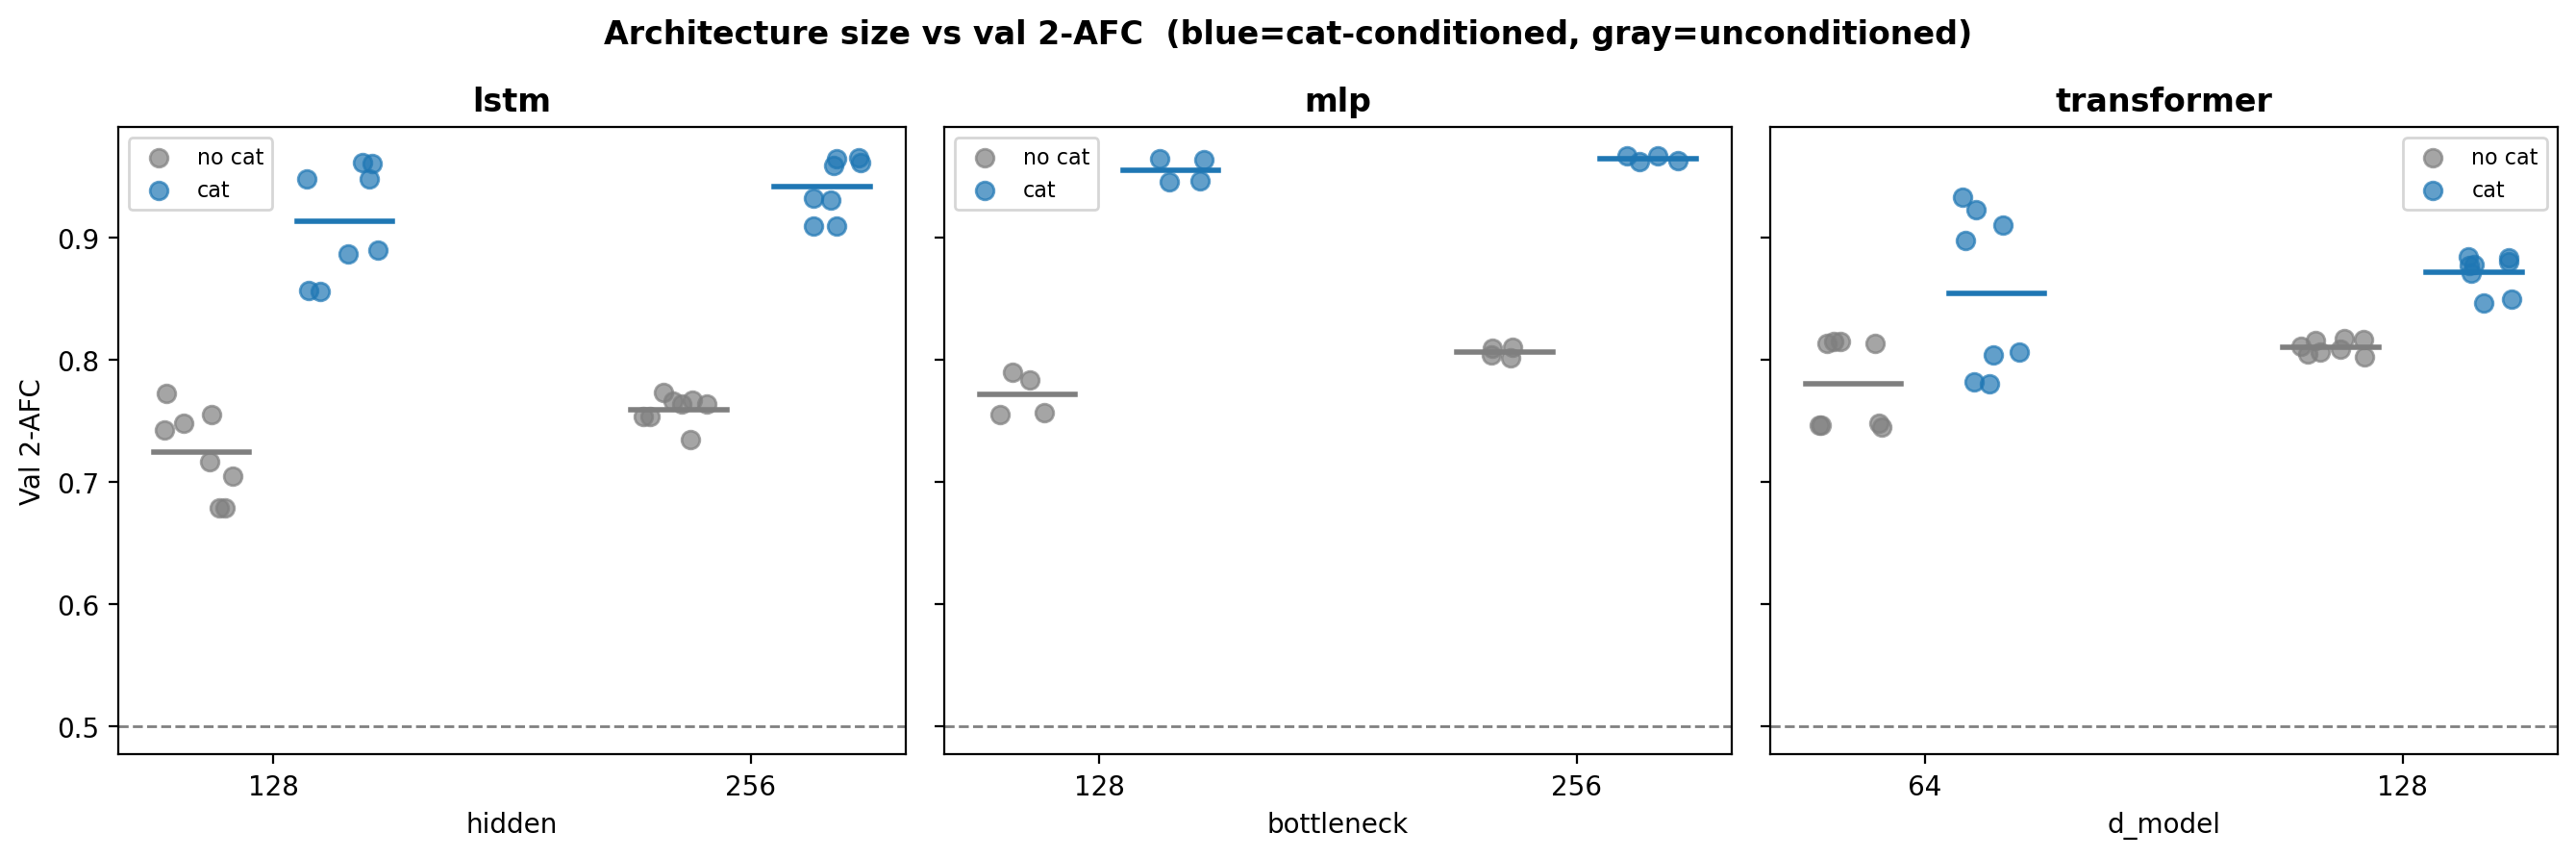

In [7]:
ARCH_PARAM = {'mlp': 'bottleneck', 'lstm': 'hidden', 'transformer': 'd_model'}

fig, axes = plt.subplots(1, len(MODELS), figsize=(4.5 * len(MODELS), 4.5), sharey=True)
rng2 = np.random.default_rng(0)

for ax, model in zip(axes, MODELS):
    sub = df[df['model'] == model].dropna(subset=['val_2afc'])
    param = ARCH_PARAM[model]
    if param not in sub.columns:
        ax.set_title(f'{model}\n(no arch param)'); continue
    levels = sorted(sub[param].unique())
    for li, lvl in enumerate(levels):
        for use_cat in [False, True]:
            vals = sub[(sub[param] == lvl) & (sub['use_category'] == use_cat)]['val_2afc'].values
            if not len(vals): continue
            x_pos = li + (0.15 if use_cat else -0.15)
            color = 'tab:blue' if use_cat else 'tab:gray'
            jitter = rng2.uniform(-0.08, 0.08, len(vals))
            ax.scatter(np.full(len(vals), x_pos) + jitter, vals,
                       color=color, alpha=0.7, s=45,
                       label=('cat' if use_cat else 'no cat') if li == 0 else '_')
            ax.plot([x_pos - 0.1, x_pos + 0.1], [vals.mean()] * 2, color=color, lw=2)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(int(l)) for l in levels])
    ax.set_xlabel(param)
    ax.set_title(model, fontweight='bold')
    ax.axhline(0.5, color='grey', lw=1, ls='--')
    ax.legend(fontsize=8)
    if ax is axes[0]:
        ax.set_ylabel('Val 2-AFC')

fig.suptitle('Architecture size vs val 2-AFC  (blue=cat-conditioned, gray=unconditioned)', fontweight='bold')
plt.tight_layout()
plt.show()

## Val vs Test generalisation

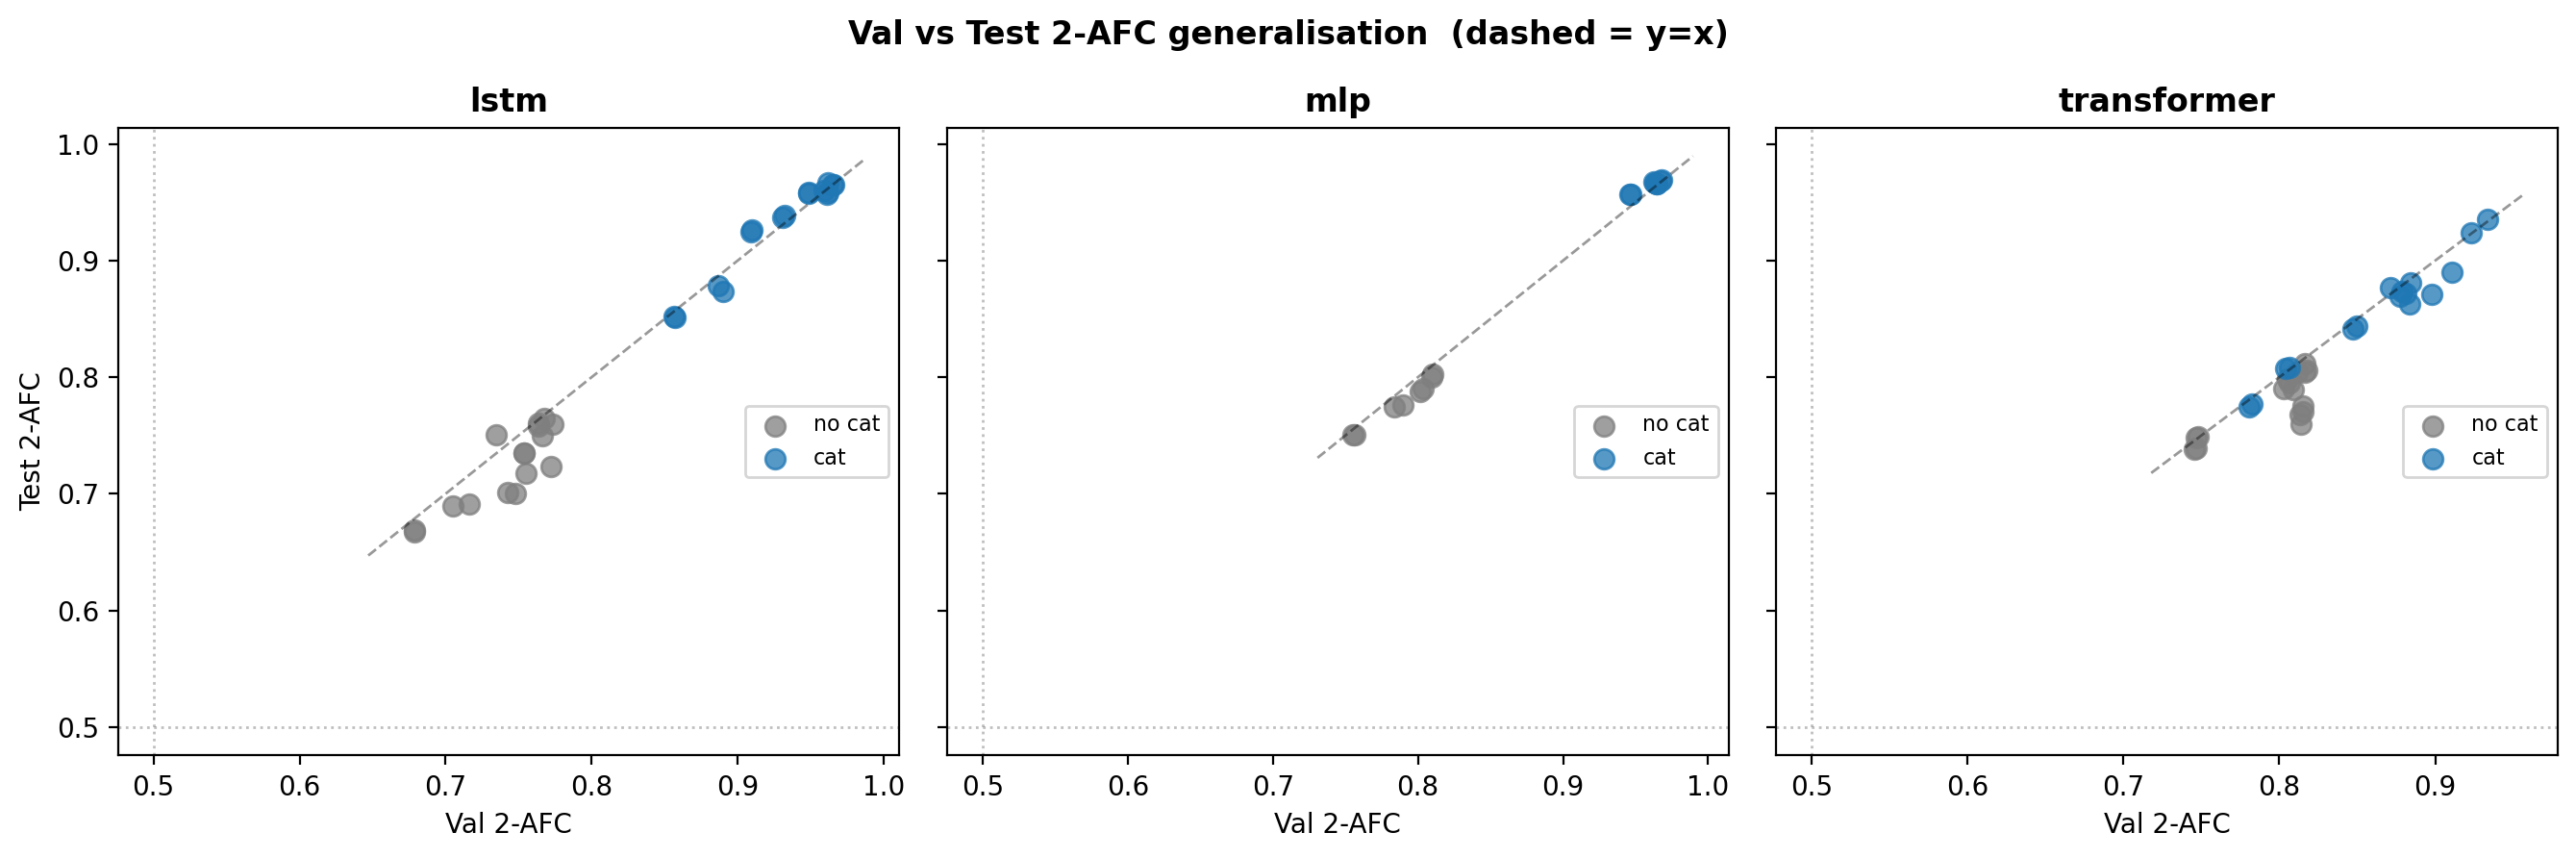

In [8]:
if has_test:
    fig, axes = plt.subplots(1, len(MODELS), figsize=(4.5 * len(MODELS), 4.5), sharey=True)
    for ax, model in zip(axes, MODELS):
        sub = df[(df['model'] == model)].dropna(subset=['val_2afc', 'test_2afc'])
        for use_cat in [False, True]:
            grp = sub[sub['use_category'] == use_cat]
            if grp.empty: continue
            color = 'tab:blue' if use_cat else 'tab:gray'
            ax.scatter(grp['val_2afc'], grp['test_2afc'], color=color, alpha=0.75, s=55,
                       label='cat' if use_cat else 'no cat')
        if not sub.empty:
            lim = [min(sub['val_2afc'].min(), sub['test_2afc'].min()) - 0.02,
                   max(sub['val_2afc'].max(), sub['test_2afc'].max()) + 0.02]
            ax.plot(lim, lim, 'k--', lw=1, alpha=0.4)
        ax.axhline(0.5, color='grey', lw=1, ls=':', alpha=0.5)
        ax.axvline(0.5, color='grey', lw=1, ls=':', alpha=0.5)
        ax.set_xlabel('Val 2-AFC')
        ax.set_title(model, fontweight='bold')
        ax.legend(fontsize=8)
        if ax is axes[0]:
            ax.set_ylabel('Test 2-AFC')
    fig.suptitle('Val vs Test 2-AFC generalisation  (dashed = y=x)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Test metrics not yet available.')

## Top-10 runs overall

In [9]:
top_cols = [c for c in [
    'model', 'use_category', 'arch', 'lr', 'weight_decay',
    'epoch', 'val_loss', 'val_2afc', 'val_cos_sim',
    'test_2afc', 'test_top1', 'test_top5', 'test_cos_sim', 'path'
] if c in df.columns]
display(df.sort_values('val_2afc', ascending=False)[top_cols].head(10).reset_index(drop=True))

,model,use_category,arch,lr,weight_decay,epoch,val_loss,val_2afc,val_cos_sim,test_2afc,test_top1,test_top5,test_cos_sim,path
0,mlp,True,bn256,0.0010,0.01,135,0.135460,0.967541,0.862381,0.969538,0.300000,0.744444,0.869455,/home/yy3658/NeurObjectGen/checkpoints/hvm/mlp...
1,mlp,True,bn256,0.0010,0.10,122,0.143589,0.967291,0.854283,0.968040,0.266667,0.688889,0.858038,/home/yy3658/NeurObjectGen/checkpoints/hvm/mlp...
2,lstm,True,h256_nl1,0.0010,0.10,167,0.165465,0.965793,0.832807,0.965418,0.266667,0.733333,0.831418,/home/yy3658/NeurObjectGen/checkpoints/hvm/lst...
3,lstm,True,h256_nl2,0.0010,0.10,126,0.159456,0.964794,0.837694,0.964669,0.266667,0.733333,0.838779,/home/yy3658/NeurObjectGen/checkpoints/hvm/lst...
4,mlp,True,bn128,0.0010,0.10,173,0.129932,0.964669,0.868426,0.965918,0.233333,0.722222,0.873865,/home/yy3658/NeurObjectGen/checkpoints/hvm/mlp...
5,mlp,True,bn128,0.0010,0.01,173,0.130234,0.964419,0.868092,0.965793,0.233333,0.711111,0.873589,/home/yy3658/NeurObjectGen/checkpoints/hvm/mlp...
6,mlp,True,bn256,0.0003,0.01,132,0.121845,0.962921,0.875612,0.966792,0.255556,0.677778,0.879184,/home/yy3658/NeurObjectGen/checkpoints/hvm/mlp...
7,mlp,True,bn256,0.0003,0.10,135,0.119407,0.962297,0.878323,0.967291,0.300000,0.677778,0.883943,/home/yy3658/NeurObjectGen/checkpoints/hvm/mlp...
8,lstm,True,h256_nl1,0.0010,0.01,169,0.163873,0.961923,0.834981,0.966417,0.311111,0.744444,0.836078,/home/yy3658/NeurObjectGen/checkpoints/hvm/lst...
9,lstm,True,h128_nl2,0.0010,0.01,130,0.154939,0.961423,0.842997,0.958302,0.288889,0.666667,0.844678,/home/yy3658/NeurObjectGen/checkpoints/hvm/lst...


## Save best HVM encoder config

In [10]:
import json
from config_const import CACHE_DIR

configs = {}
for use_cat in [False, True]:
    sub = df[df['use_category'] == use_cat]
    if sub.empty:
        continue
    best = sub.sort_values('val_2afc', ascending=False).iloc[0]
    key = 'hvm_siglip_cat' if use_cat else 'hvm_siglip'
    cfg = {
        'dataset':       'hvm',
        'target':        'siglip',
        'use_category':  bool(use_cat),
        'model':         best['model'],
        'val_2afc':      float(best['val_2afc']),
        'checkpoint':    best['path'],
    }
    for k in ['bottleneck', 'hidden', 'n_layers', 'd_model', 'n_heads',
              'shared_dim', 'dropout', 'lr', 'weight_decay']:
        if k in best and pd.notna(best[k]):
            cfg[k] = float(best[k]) if isinstance(best[k], float) else int(best[k])
    configs[key] = cfg

out_path = CACHE_DIR / 'best_hvm_encoder_config.json'
with open(out_path, 'w') as f:
    json.dump(configs, f, indent=2)
print(f'Saved to {out_path}')
for k, cfg in configs.items():
    print(f"  {k}: {cfg['model']} arch — val_2afc={cfg['val_2afc']:.4f}")
    print(f"    {cfg['checkpoint']}")

Saved to /home/yy3658/NeurObjectGen/cache/best_hvm_encoder_config.json
  hvm_siglip: transformer arch — val_2afc=0.8174
    /home/yy3658/NeurObjectGen/checkpoints/hvm/transformer/siglip/d128_nh4_nl1_do0.1_lr0.0003_wd0.1_tn0.02_bs64_t0.07_uw0.1/best.pt
  hvm_siglip_cat: mlp arch — val_2afc=0.9675
    /home/yy3658/NeurObjectGen/checkpoints/hvm/mlp/siglip/bn256_do0.1_lr0.001_wd0.01_tn0.02_bs64_t0.07_uw0.1_cat/best.pt
